# Causality

**Module 4: Statistical Testing** | Lean Six Sigma Data Analytics

---

## Correlation Does Not Imply Causation

This is a statement that statistics teachers love to repeat. Why?

| Term | Meaning |
|------|--------|
| **Correlation** | Two things move in the same direction |
| **Causation** | One thing **causes** the other to change |

Understanding the difference is critical for **interpreting your results correctly**.

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

print('Ready to explore causality!')


Ready to explore causality!


---

## What is Causality?

**Causality** is about cause and effect relationships:

> When you change your **X variable** (and nothing else), your **Y variable** will change as a result.

```
┌─────────┐         ┌─────────┐
│    X    │  ────►  │    Y    │
│ (Cause) │         │ (Effect)│
└─────────┘         └─────────┘
```

**Example:** If children grow taller, they also become heavier.
- Growing (X) **causes** weight to increase (Y)

---

## Four Common Causality Errors

| Error Type | Description |
|------------|------------|
| **1. Wrong Direction** | You assume X causes Y, but Y actually causes X |
| **2. Time Problem** | Two variables change together over time but are unrelated |
| **3. Third Variable** | A hidden variable Z causes both X and Y |
| **4. Underlying Variable** | An underlying factor explains X's apparent effect on Y |

---

## Error 1: Wrong Direction of Causality

### Example: Extraction Time and Caffeine Percentage

You want to reduce extraction time for decaffeinated coffee (shorter = more profitable).

You measure extraction time and caffeine percentage, then make a graph.

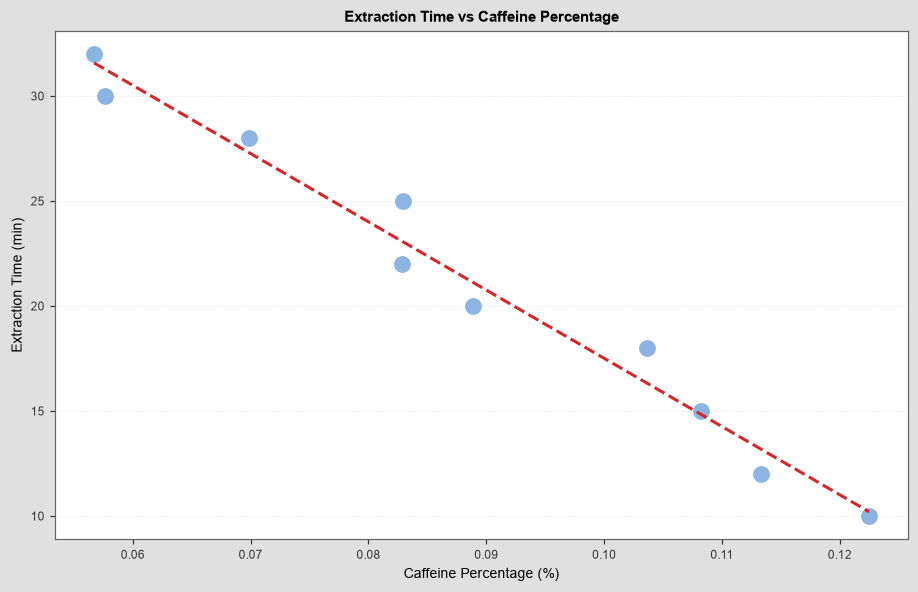

WRONG CONCLUSION:
  "Caffeine percentage influences extraction time."
  "To have low extraction time, you need beans with lots of caffeine."

CORRECT CONCLUSION:
  "Extraction time influences caffeine percentage."
  "Longer extraction removes more caffeine."


In [2]:
# Simulated data: Extraction time vs Caffeine percentage
extraction_time = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 32])
caffeine_pct = 0.15 - 0.003 * extraction_time + np.random.normal(0, 0.005, len(extraction_time))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(caffeine_pct, extraction_time, s=100, color=ms.HIST_FILL)
ax.set_xlabel('Caffeine Percentage (%)')
ax.set_ylabel('Extraction Time (min)')
ax.set_title('Extraction Time vs Caffeine Percentage')

# Add trend line
z = np.polyfit(caffeine_pct, extraction_time, 1)
p = np.poly1d(z)
x_line = np.linspace(caffeine_pct.min(), caffeine_pct.max(), 100)
ax.plot(x_line, p(x_line), color=ms.RED, linestyle='--', lw=2)

plt.show()

print('WRONG CONCLUSION:')
print('  "Caffeine percentage influences extraction time."')
print('  "To have low extraction time, you need beans with lots of caffeine."')
print()
print('CORRECT CONCLUSION:')
print('  "Extraction time influences caffeine percentage."')
print('  "Longer extraction removes more caffeine."')

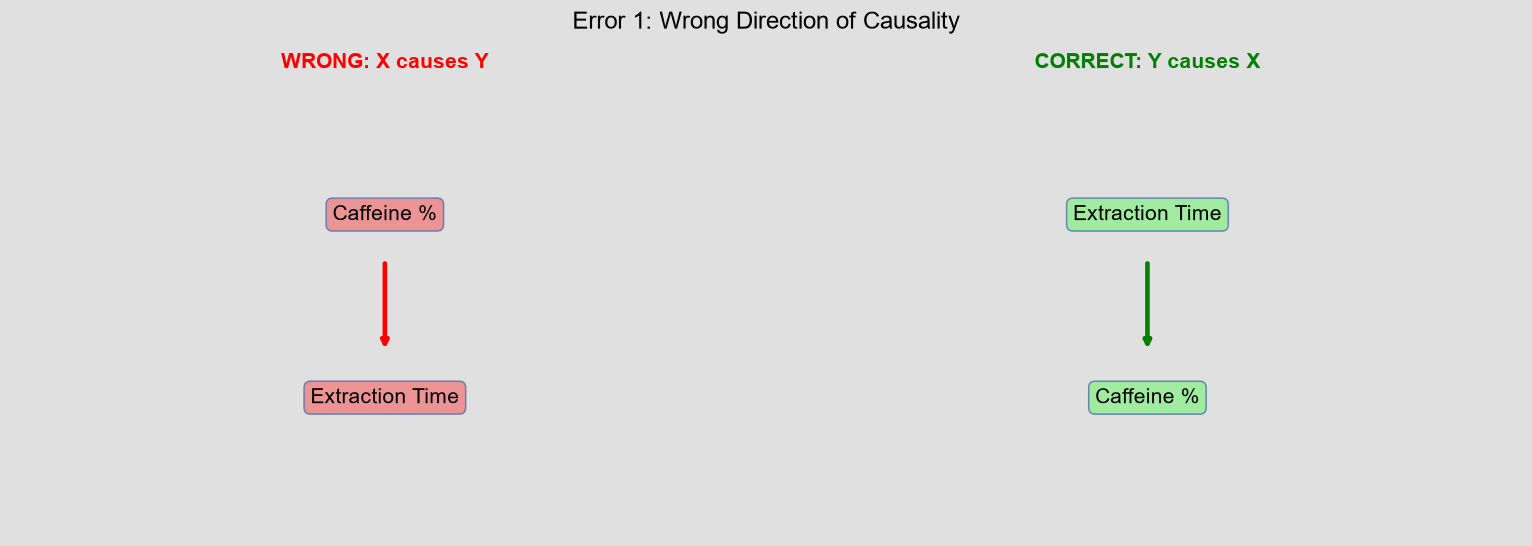

LESSON: Statistics alone cannot tell you the direction of causality.
        You must think logically about what causes what.


In [3]:
# Visualize the error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wrong direction
axes[0].text(0.5, 0.7, 'Caffeine %', ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
axes[0].annotate('', xy=(0.5, 0.4), xytext=(0.5, 0.6),
                 arrowprops=dict(arrowstyle='->', lw=3, color='red'))
axes[0].text(0.5, 0.3, 'Extraction Time', ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))
axes[0].set_title('WRONG: X causes Y', fontsize=14, color='red')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].axis('off')

# Correct direction
axes[1].text(0.5, 0.7, 'Extraction Time', ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[1].annotate('', xy=(0.5, 0.4), xytext=(0.5, 0.6),
                 arrowprops=dict(arrowstyle='->', lw=3, color='green'))
axes[1].text(0.5, 0.3, 'Caffeine %', ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[1].set_title('CORRECT: Y causes X', fontsize=14, color='green')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis('off')

plt.suptitle('Error 1: Wrong Direction of Causality', fontsize=16)
plt.tight_layout()
plt.show()

print('LESSON: Statistics alone cannot tell you the direction of causality.')
print('        You must think logically about what causes what.')

---

## Error 2: The Time Problem

### Example: Internet Explorer and Murder Rate

Two variables that both change over time may appear correlated but are actually unrelated.

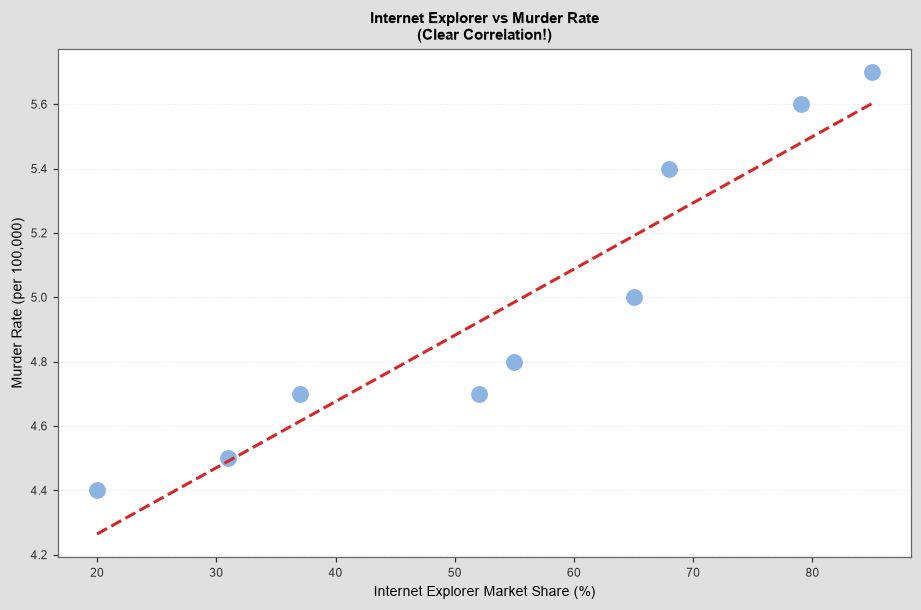

WRONG CONCLUSION:
  "To reduce murders, we should ban Internet Explorer!"

This is obviously absurd. So what is really happening?


In [4]:
# Real data (approximate): Internet Explorer market share vs US murder rate
years = np.arange(2006, 2015)
ie_share = np.array([85, 79, 68, 65, 55, 52, 37, 31, 20])  # % market share
murder_rate = np.array([5.7, 5.6, 5.4, 5.0, 4.8, 4.7, 4.7, 4.5, 4.4])  # per 100,000

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(ie_share, murder_rate, s=100, color=ms.HIST_FILL)

# Trend line
z = np.polyfit(ie_share, murder_rate, 1)
p = np.poly1d(z)
x_line = np.linspace(ie_share.min(), ie_share.max(), 100)
ax.plot(x_line, p(x_line), color=ms.RED, linestyle='--', lw=2)

ax.set_xlabel('Internet Explorer Market Share (%)')
ax.set_ylabel('Murder Rate (per 100,000)')
ax.set_title('Internet Explorer vs Murder Rate\n(Clear Correlation!)')
plt.show()

print('WRONG CONCLUSION:')
print('  "To reduce murders, we should ban Internet Explorer!"')
print()
print('This is obviously absurd. So what is really happening?')

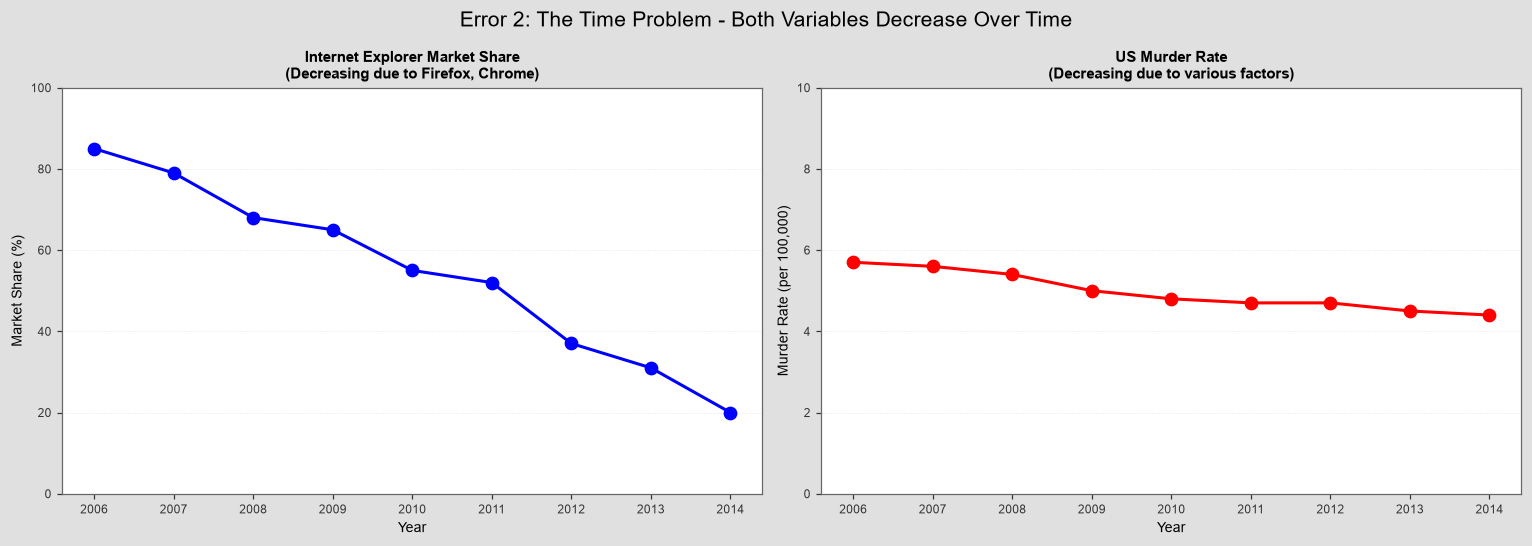

EXPLANATION:
  Both variables decreased over time due to DIFFERENT causes.
  IE lost share to Firefox/Chrome. Murder rate decreased for other reasons.
  They are NOT causally related - just coincidentally trending together.


In [5]:
# Show the time series separately
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IE market share over time
axes[0].plot(years, ie_share, 'b-o', lw=2, markersize=8)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Market Share (%)')
axes[0].set_title('Internet Explorer Market Share\n(Decreasing due to Firefox, Chrome)')
axes[0].set_ylim(0, 100)

# Murder rate over time
axes[1].plot(years, murder_rate, 'r-o', lw=2, markersize=8)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Murder Rate (per 100,000)')
axes[1].set_title('US Murder Rate\n(Decreasing due to various factors)')
axes[1].set_ylim(0, 10)

plt.suptitle('Error 2: The Time Problem - Both Variables Decrease Over Time', fontsize=14)
plt.tight_layout()
plt.show()

print('EXPLANATION:')
print('  Both variables decreased over time due to DIFFERENT causes.')
print('  IE lost share to Firefox/Chrome. Murder rate decreased for other reasons.')
print('  They are NOT causally related - just coincidentally trending together.')

---

## Error 3: The Third Variable Problem

### Example: Firemen and Fire Damage

You work at an insurance company and want to reduce fire damage claims.

You find a potential factor: **number of firemen sent**.

**Expected:** More firemen → Less damage

**What you find:** More firemen → MORE damage!

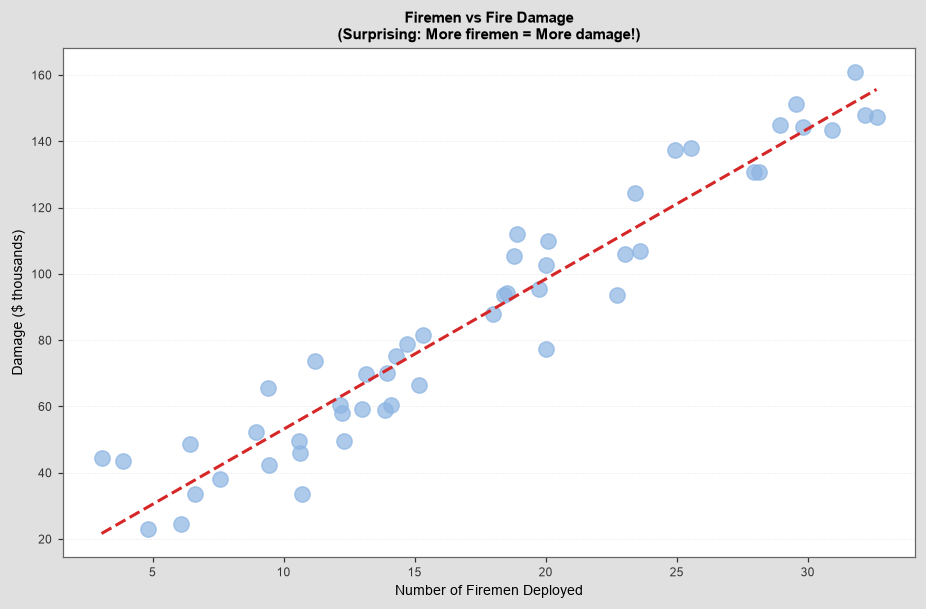

WRONG CONCLUSION:
  "Sending more firemen causes more damage!"
  "We should send fewer firemen to reduce damage!"

Obviously this is wrong. What is really happening?


In [6]:
# Simulated data: Firemen vs Damage
# The hidden variable is fire size
fire_size = np.random.uniform(1, 10, 50)  # Hidden variable
firemen = 2 + 3 * fire_size + np.random.normal(0, 2, 50)  # More firemen for bigger fires
damage = 10000 + 15000 * fire_size + np.random.normal(0, 5000, 50)  # More damage for bigger fires

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(firemen, damage/1000, s=100, color=ms.HIST_FILL, alpha=0.7)

# Trend line
z = np.polyfit(firemen, damage/1000, 1)
p = np.poly1d(z)
x_line = np.linspace(firemen.min(), firemen.max(), 100)
ax.plot(x_line, p(x_line), color=ms.RED, linestyle='--', lw=2)

ax.set_xlabel('Number of Firemen Deployed')
ax.set_ylabel('Damage ($ thousands)')
ax.set_title('Firemen vs Fire Damage\n(Surprising: More firemen = More damage!)')
plt.show()

print('WRONG CONCLUSION:')
print('  "Sending more firemen causes more damage!"')
print('  "We should send fewer firemen to reduce damage!"')
print()
print('Obviously this is wrong. What is really happening?')

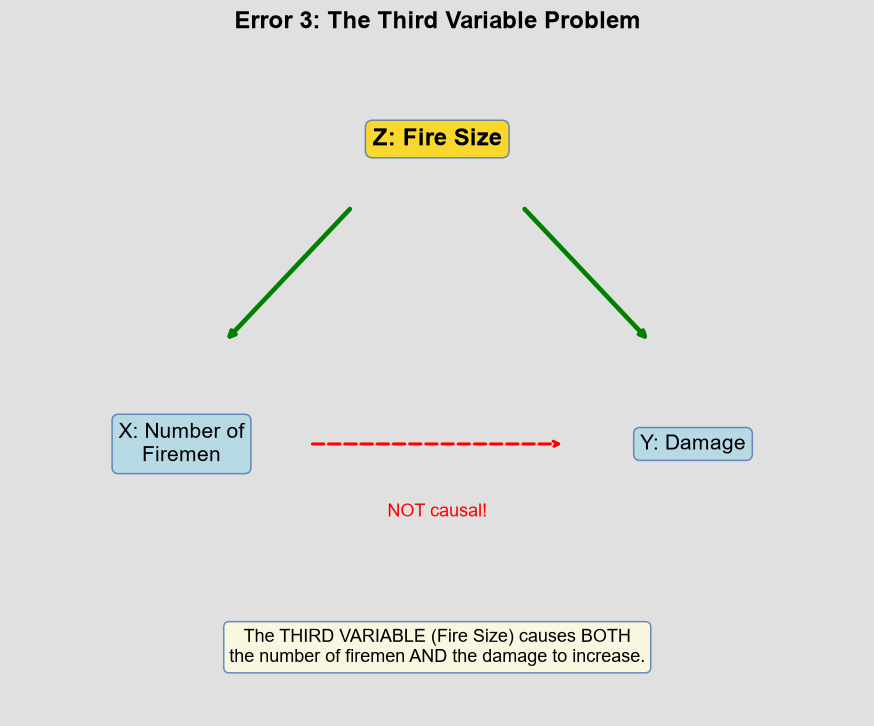

CORRECT EXPLANATION:
  Bigger fires → More firemen sent
  Bigger fires → More damage
  Fire size (Z) causes BOTH X and Y to change together.


In [7]:
# Reveal the third variable
fig, ax = plt.subplots(figsize=(10, 8))

# Diagram showing the third variable
ax.text(0.5, 0.85, 'Z: Fire Size', ha='center', va='center', fontsize=16, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='gold', alpha=0.8))

ax.text(0.2, 0.4, 'X: Number of\nFiremen', ha='center', va='center', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax.text(0.8, 0.4, 'Y: Damage', ha='center', va='center', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Arrows from Z to X and Y
ax.annotate('', xy=(0.25, 0.55), xytext=(0.4, 0.75),
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax.annotate('', xy=(0.75, 0.55), xytext=(0.6, 0.75),
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))

# Wrong arrow from X to Y
ax.annotate('', xy=(0.65, 0.4), xytext=(0.35, 0.4),
            arrowprops=dict(arrowstyle='->', lw=2, color='red', linestyle='--'))
ax.text(0.5, 0.3, 'NOT causal!', ha='center', va='center', fontsize=12, color='red')

ax.text(0.5, 0.1, 'The THIRD VARIABLE (Fire Size) causes BOTH\nthe number of firemen AND the damage to increase.',
        ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Error 3: The Third Variable Problem', fontsize=16)
plt.show()

print('CORRECT EXPLANATION:')
print('  Bigger fires → More firemen sent')
print('  Bigger fires → More damage')
print('  Fire size (Z) causes BOTH X and Y to change together.')

---

## Error 4: The Underlying Variable Problem

### Example: Extraction Machine and Caffeine

You found that **Machine 3** produces coffee that does not meet the caffeine specification.

**Conclusion:** Machine 3 needs to be replaced.

But wait...

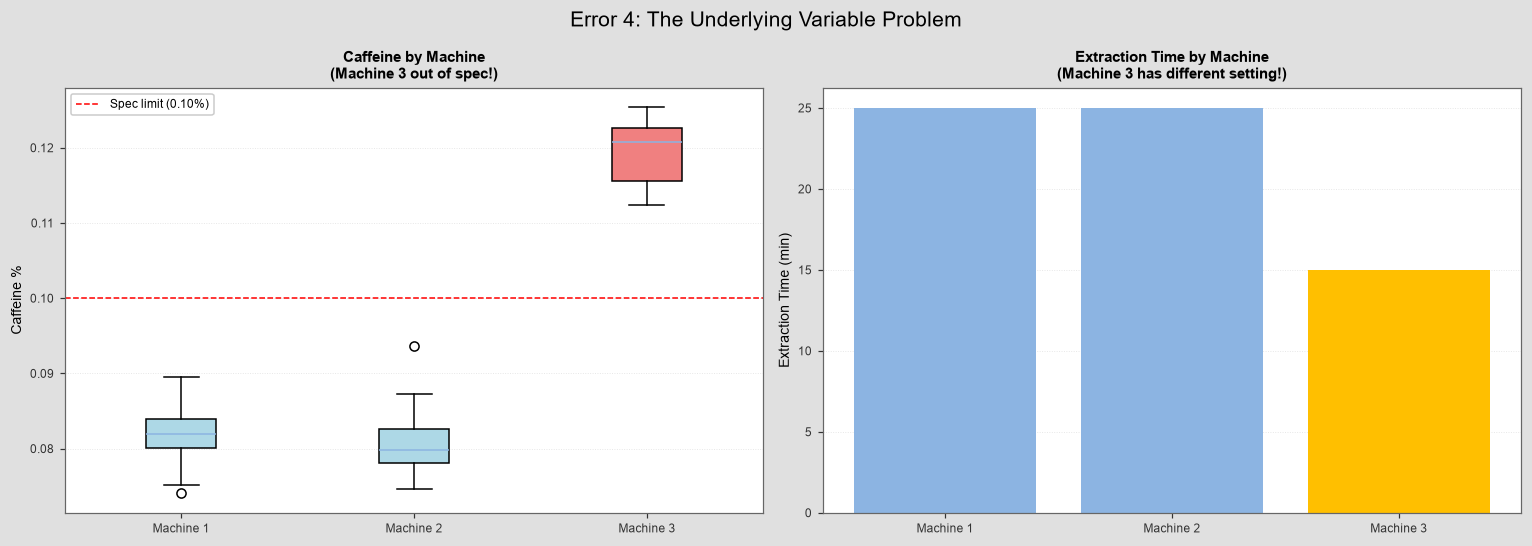

WRONG CONCLUSION:
  "Machine 3 is broken and needs to be replaced."

CORRECT CONCLUSION:
  "Machine 3 has different extraction time settings."
  "The UNDERLYING VARIABLE (extraction time) is the real cause."
  "Fix the settings, not the machine!"


In [8]:
# Simulated data: Machine vs Caffeine
machines = ['Machine 1', 'Machine 2', 'Machine 3']
caffeine_by_machine = {
    'Machine 1': np.random.normal(0.08, 0.005, 20),
    'Machine 2': np.random.normal(0.08, 0.005, 20),
    'Machine 3': np.random.normal(0.12, 0.005, 20)  # Higher caffeine
}

# Underlying variable: Extraction time
extraction_by_machine = {
    'Machine 1': 25,  # minutes
    'Machine 2': 25,
    'Machine 3': 15   # Less time = more caffeine remains
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Machine vs Caffeine
data = [caffeine_by_machine[m] for m in machines]
bp = axes[0].boxplot(data, tick_labels=machines, patch_artist=True)
colors = ['lightblue', 'lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].axhline(y=0.10, color='red', linestyle='--', label='Spec limit (0.10%)')
axes[0].set_ylabel('Caffeine %')
axes[0].set_title('Caffeine by Machine\n(Machine 3 out of spec!)')
axes[0].legend()

# Graph 2: Machine vs Extraction Time
times = [extraction_by_machine[m] for m in machines]
colors = [ms.HIST_FILL, ms.HIST_FILL, ms.GOLD]
axes[1].bar(machines, times, color=colors)
axes[1].set_ylabel('Extraction Time (min)')
axes[1].set_title('Extraction Time by Machine\n(Machine 3 has different setting!)')

plt.suptitle('Error 4: The Underlying Variable Problem', fontsize=14)
plt.tight_layout()
plt.show()

print('WRONG CONCLUSION:')
print('  "Machine 3 is broken and needs to be replaced."')
print()
print('CORRECT CONCLUSION:')
print('  "Machine 3 has different extraction time settings."')
print('  "The UNDERLYING VARIABLE (extraction time) is the real cause."')
print('  "Fix the settings, not the machine!"')

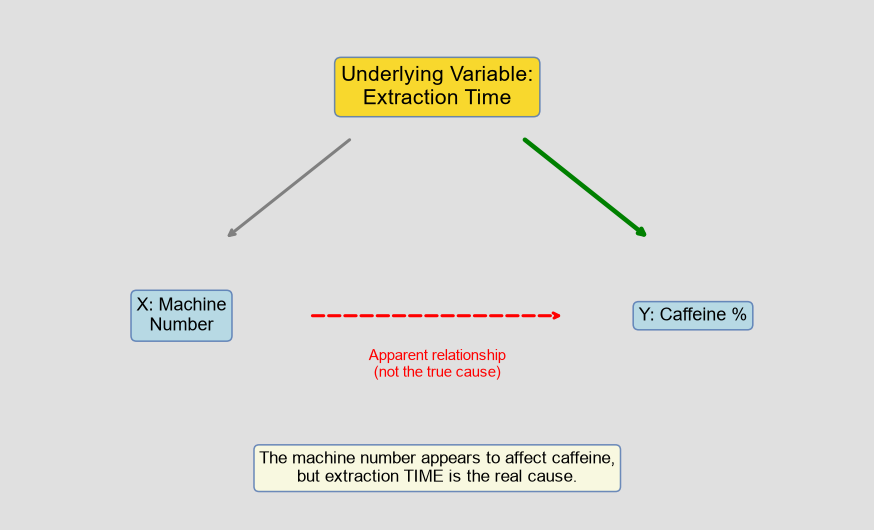

In [9]:
# Visualize the underlying variable structure
fig, ax = plt.subplots(figsize=(10, 6))

ax.text(0.5, 0.85, 'Underlying Variable:\nExtraction Time', ha='center', va='center', fontsize=14,
        bbox=dict(boxstyle='round', facecolor='gold', alpha=0.8))

ax.text(0.2, 0.4, 'X: Machine\nNumber', ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

ax.text(0.8, 0.4, 'Y: Caffeine %', ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Arrows
ax.annotate('', xy=(0.25, 0.55), xytext=(0.4, 0.75),
            arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
ax.annotate('', xy=(0.75, 0.55), xytext=(0.6, 0.75),
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))

ax.annotate('', xy=(0.65, 0.4), xytext=(0.35, 0.4),
            arrowprops=dict(arrowstyle='->', lw=2, color='red', linestyle='--'))
ax.text(0.5, 0.28, 'Apparent relationship\n(not the true cause)', ha='center', fontsize=10, color='red')

ax.text(0.5, 0.1, 'The machine number appears to affect caffeine,\nbut extraction TIME is the real cause.',
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.show()

---

## How to Ensure Correct Causality

### Option 1: Controlled Experiment

- **Manipulate** your X variable yourself
- **Keep all other factors constant**
- Observe what happens to Y

**Fire Example:** Send a random number of firemen to fires of equal size, then study the damage.

### Option 2: Study the Literature

- Read research that argues why (or why not) a relationship is causal
- Use domain expertise

### Option 3: Logical Thinking

- Consider **time order**: What came first?
- Ask: Does it make sense that X causes Y?
- Look for hidden third variables

---

## Summary: Four Causality Errors

In [10]:
# Summary table
print('FOUR CAUSALITY ERRORS')
print('=' * 70)
print()
print('1. WRONG DIRECTION')
print('   You assume X causes Y, but Y actually causes X')
print('   Example: Caffeine % → Extraction Time (wrong direction)')
print()
print('2. TIME PROBLEM')
print('   Two variables change together over time but are unrelated')
print('   Example: IE market share and murder rate both decreased')
print()
print('3. THIRD VARIABLE')
print('   A hidden variable Z causes both X and Y')
print('   Example: Fire size causes both firemen count and damage')
print()
print('4. UNDERLYING VARIABLE')
print('   An underlying factor explains X\'s apparent effect on Y')
print('   Example: Extraction time (not machine) causes caffeine levels')
print()
print('=' * 70)
print('HOW TO AVOID THESE ERRORS:')
print('  - Controlled experiments (manipulate X, hold others constant)')
print('  - Study the literature')
print('  - Logical thinking and time order')

FOUR CAUSALITY ERRORS

1. WRONG DIRECTION
   You assume X causes Y, but Y actually causes X
   Example: Caffeine % → Extraction Time (wrong direction)

2. TIME PROBLEM
   Two variables change together over time but are unrelated
   Example: IE market share and murder rate both decreased

3. THIRD VARIABLE
   A hidden variable Z causes both X and Y
   Example: Fire size causes both firemen count and damage

4. UNDERLYING VARIABLE
   An underlying factor explains X's apparent effect on Y
   Example: Extraction time (not machine) causes caffeine levels

HOW TO AVOID THESE ERRORS:
  - Controlled experiments (manipulate X, hold others constant)
  - Study the literature
  - Logical thinking and time order


---

## Key Takeaways

- **Correlation does not imply causation**
- **Four common errors:**
  1. Wrong direction of causality
  2. Time problem (spurious trends)
  3. Third variable problem (confounding)
  4. Underlying variable problem
- **How to establish causality:**
  - Controlled experiments
  - Literature and domain expertise
  - Logical thinking (time order, does it make sense?)
- **Always be careful when interpreting causal relationships!**